# Forecasting Item Sales — Three Bayesian Models

OptiStock provides three forecasting models, each suited to a different data-generating process. This notebook introduces each one using **synthetic data tailored to highlight its specific strengths**, then shows how to plug any fitted model into `ForecastSolver` via `get_demand_distribution`.

| Model | Best for | Key mechanism |
|---|---|---|
| **BayesTimeSeries** | Stable seasonal patterns + known events | Fourier decomposition + event indicators |
| **MediaMixModel** | Sales driven by marketing spend | Adstock carry-over + saturation curves |
| **UnivariateSSM** | Evolving trends, structural breaks | Kalman filter/smoother on latent states |

All three expose the same `fit → forecast → get_demand_distribution` interface.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Dataset 1: BayesTimeSeries ─────────────────────────────────────────────
# Two years of daily sales with stable weekly/yearly seasonality and two events.
# Fourier decomposition should cleanly recover each component.

N = 730
dates_b = pd.date_range("2022-01-01", periods=N, freq="D")
t = np.arange(N)

trend_b   = 100 + 0.06 * t
weekly_b  = 20 * np.sin(2 * np.pi * t / 7) + 10 * np.cos(2 * np.pi * t / 7)
yearly_b  = (25 * np.sin(2 * np.pi * t / 365.25)
           + 15 * np.cos(2 * np.pi * t / 365.25)
           +  8 * np.sin(4 * np.pi * t / 365.25))

# Black Friday (4th Friday of November) — 5-day spike
event_b = np.zeros(N)
for i, d in enumerate(dates_b):
    if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28:
        event_b[i : min(i + 5, N)] += 70
# Christmas week
for i, d in enumerate(dates_b):
    if d.month == 12 and 20 <= d.day <= 26:
        event_b[i] += 50

sales_b = trend_b + weekly_b + yearly_b + event_b + np.random.normal(0, 8, N)
df_bayes = pd.DataFrame({"date": dates_b.astype(str), "sales": np.maximum(sales_b, 10).round(1)})

# ── Dataset 2: MediaMixModel ───────────────────────────────────────────────
# Weekly sales driven by TV burst campaigns (adstock) and always-on digital
# spend (saturation). The Fourier model cannot recover these channel effects.

N_w = 130
dates_m = pd.date_range("2022-01-01", periods=N_w, freq="W-MON")
t_w = np.arange(N_w)

baseline_m = 600 #+ 0.4 * t_w

# TV: 4 burst campaigns with geometric adstock (alpha=0.5, window=8 weeks)
tv_spend = np.zeros(N_w)
for s, e in [(8, 14), (30, 37), (56, 63), (90, 98)]:
    tv_spend[s:e] = np.random.uniform(300, 700, e - s)

tv_adstocked = np.zeros(N_w)
for i in range(N_w):
    for lag in range(min(8, i + 1)):
        tv_adstocked[i] += tv_spend[i - lag] * (0.5 ** lag)
tv_contribution = 200 * tv_adstocked / (tv_adstocked.max() + 1)

# Digital: always-on spend with logistic saturation
digital_spend = 80 + 60 * np.abs(np.sin(2 * np.pi * t_w / 52)) + np.random.uniform(0, 40, N_w)
digital_contribution = 180 / (1 + np.exp(-0.04 * (digital_spend - 100)))

sales_m = baseline_m + tv_contribution + digital_contribution + np.random.normal(0, 25, N_w)
df_mmm = pd.DataFrame({
    "date":          pd.to_datetime(dates_m),
    "sales":         np.maximum(sales_m, 200).round(1),
    "tv_spend":      tv_spend.round(1),
    "digital_spend": digital_spend.round(1),
})

# ── Dataset 3: UnivariateSSM ────────────────────────────────────────────────
# Monthly sales with a trend reversal at month 20 and a seasonal amplitude
# that doubles over the series. Static Fourier models cannot track either.

N_s = 48
dates_s = pd.date_range("2021-01-01", periods=N_s, freq="MS")
t_s = np.arange(N_s)

trend_s    = np.where(t_s < 20, 400 - 6 * t_s, 280 + 9 * (t_s - 20))
amplitude  = np.linspace(30, 80, N_s)          # growing seasonal amplitude
seasonal_s = amplitude * np.sin(2 * np.pi * t_s / 12)

sales_s = trend_s + seasonal_s + np.random.normal(0, 12, N_s)
df_ssm = pd.DataFrame({"date": dates_s, "sales": np.maximum(sales_s, 50).round(1)}).set_index("date")

print("Dataset shapes:")
print(f"  df_bayes : {df_bayes.shape}  — daily, 2 yr, stable seasonality + events")
print(f"  df_mmm   : {df_mmm.shape}  — weekly, 2.5 yr, spend-driven")
print(f"  df_ssm   : {df_ssm.shape}   — monthly, 4 yr, structural break")

Dataset shapes:
  df_bayes : (730, 2)  — daily, 2 yr, stable seasonality + events
  df_mmm   : (130, 4)  — weekly, 2.5 yr, spend-driven
  df_ssm   : (48, 1)   — monthly, 4 yr, structural break


## Dataset Overview

Each dataset was designed so that a *different* model has a structural advantage:

- **Dataset 1** has exact Fourier structure — BayesTimeSeries should recover the weekly and yearly components cleanly and attribute the event spikes correctly.
- **Dataset 2** has sales driven entirely by marketing spend, with a realistic adstock tail after each campaign ends. BayesTimeSeries would absorb this as spurious seasonality; only MMM can attribute it to the channels.
- **Dataset 3** has a trend that *reverses direction* at month 20 and a seasonal amplitude that doubles over the observation period. Static models would fit poorly; the SSM tracks these changes via evolving latent states.

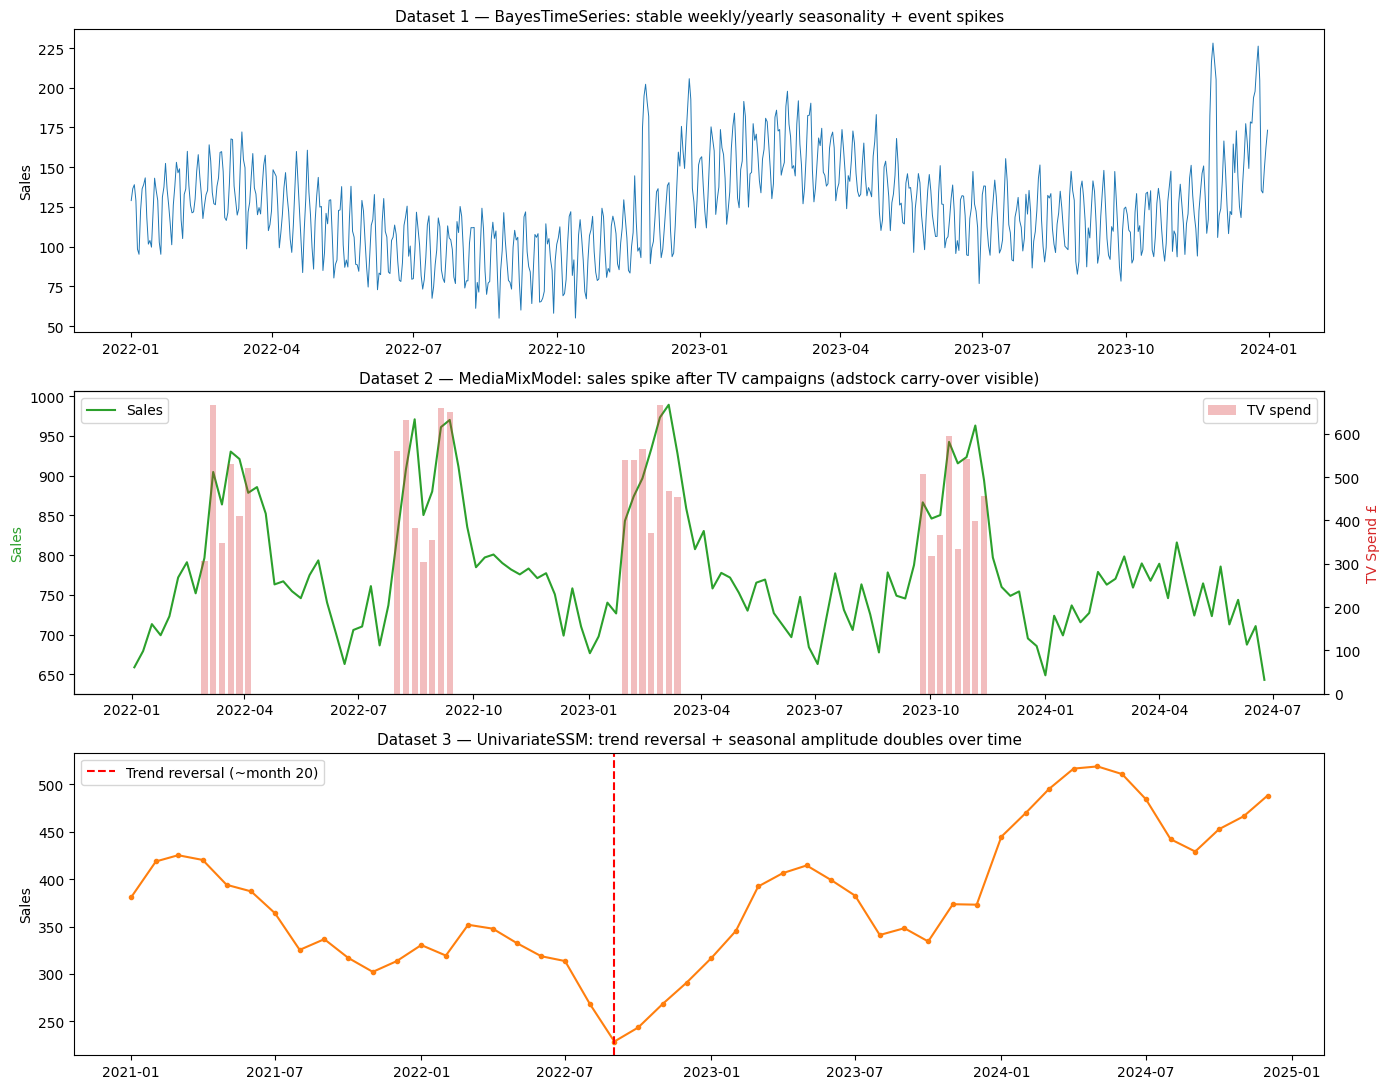

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# ── Dataset 1: daily seasonal pattern + events ──────────────────────────────
ax = axes[0]
ax.plot(pd.to_datetime(df_bayes["date"]), df_bayes["sales"], lw=0.7, color="tab:blue")
ax.set_title("Dataset 1 — BayesTimeSeries: stable weekly/yearly seasonality + event spikes", fontsize=11)
ax.set_ylabel("Sales")

# ── Dataset 2: spend-driven sales ──────────────────────────────────────────
ax = axes[1]
ax2 = ax.twinx()
ax.plot(df_mmm["date"], df_mmm["sales"], lw=1.5, color="tab:green", label="Sales")
ax2.bar(df_mmm["date"], df_mmm["tv_spend"], alpha=0.3, color="tab:red", width=5, label="TV spend")
ax.set_title("Dataset 2 — MediaMixModel: sales spike after TV campaigns (adstock carry-over visible)", fontsize=11)
ax.set_ylabel("Sales", color="tab:green")
ax2.set_ylabel("TV Spend £", color="tab:red")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")

# ── Dataset 3: structural break + evolving seasonality ──────────────────────
ax = axes[2]
ax.plot(df_ssm.index, df_ssm["sales"], lw=1.5, color="tab:orange", marker="o", ms=3)
ax.axvline(pd.Timestamp("2022-09-01"), color="red", linestyle="--", lw=1.5, label="Trend reversal (~month 20)")
ax.set_title("Dataset 3 — UnivariateSSM: trend reversal + seasonal amplitude doubles over time", fontsize=11)
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
plt.show()

---
## Model 1: BayesTimeSeries (Parametric Fourier Regressor)

**When to use:** sales exhibit clear, *stable* seasonal cycles at known periods (7-day, 365-day, etc.) and you want an interpretable, component-wise decomposition.

The model is:

$$\text{sales}(t) = \underbrace{\alpha + \beta t}_{\text{trend}} + \underbrace{\sum_k \left(a_k \sin\tfrac{2\pi k t}{P} + b_k \cos\tfrac{2\pi k t}{P}\right)}_{\text{seasonality (Fourier)}} + \underbrace{\sum_j \gamma_j \mathbf{1}_{e_j}(t)}_{\text{events}} + \varepsilon$$

All coefficients are given Bayesian priors. The posterior gives uncertainty over each component, not just a point estimate.

**Advantage over MMM:** handles multiple seasonal periods simultaneously with a single unified model.  
**Advantage over SSM:** fast to fit; the `plot_components()` output is directly interpretable from the prior specification.  
**Weakness:** the seasonal structure is fixed — if the amplitude or shape of a season changes over time the model will underfit.

In [4]:
from optistock.forecasting.linear_regressors import BayesTimeSeries

# Withhold last 90 days for validation
df_train_b = df_bayes.iloc[:-90].copy()
df_test_b  = df_bayes.iloc[-90:].copy()

seasonal_config = {
    "weekly": (7, 3),       # 7-day period, 3 Fourier harmonics (sin + cos pairs)
    "yearly": (365.25, 4),  # 365.25-day period, 4 harmonics
}

bayes_model = BayesTimeSeries(df_train_b, seasonal_config=seasonal_config)

# Register events across the full date range (training + forecast window)
all_dates = pd.to_datetime(df_bayes["date"])
bf_dates   = [d for d in all_dates if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28]
xmas_dates = [d for d in all_dates if d.month == 12 and 20 <= d.day <= 26]

idata_b = bayes_model.create_events(
    {"black_friday": bf_dates, "christmas": xmas_dates}
).fit(target="sales", date_col="date", chains=2, samples=1000)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.38,7
,2000,0,0.31,15


Sampling: [y]


Output()

### Component decomposition

`plot_components()` shows the posterior mean and 94% HDI for each additive component. Since we injected a clean Fourier signal into the data, the model should recover:
- A smooth upward **trend**
- Clear **weekly** oscillation  
- A **yearly** curve with a summer peak and winter dip  
- Two sharp **event** spikes at Black Friday and Christmas

Inspect whether the posterior HDIs are tight (the model is confident) and whether the components are plausible — this is the main diagnostic tool before running the forecast.

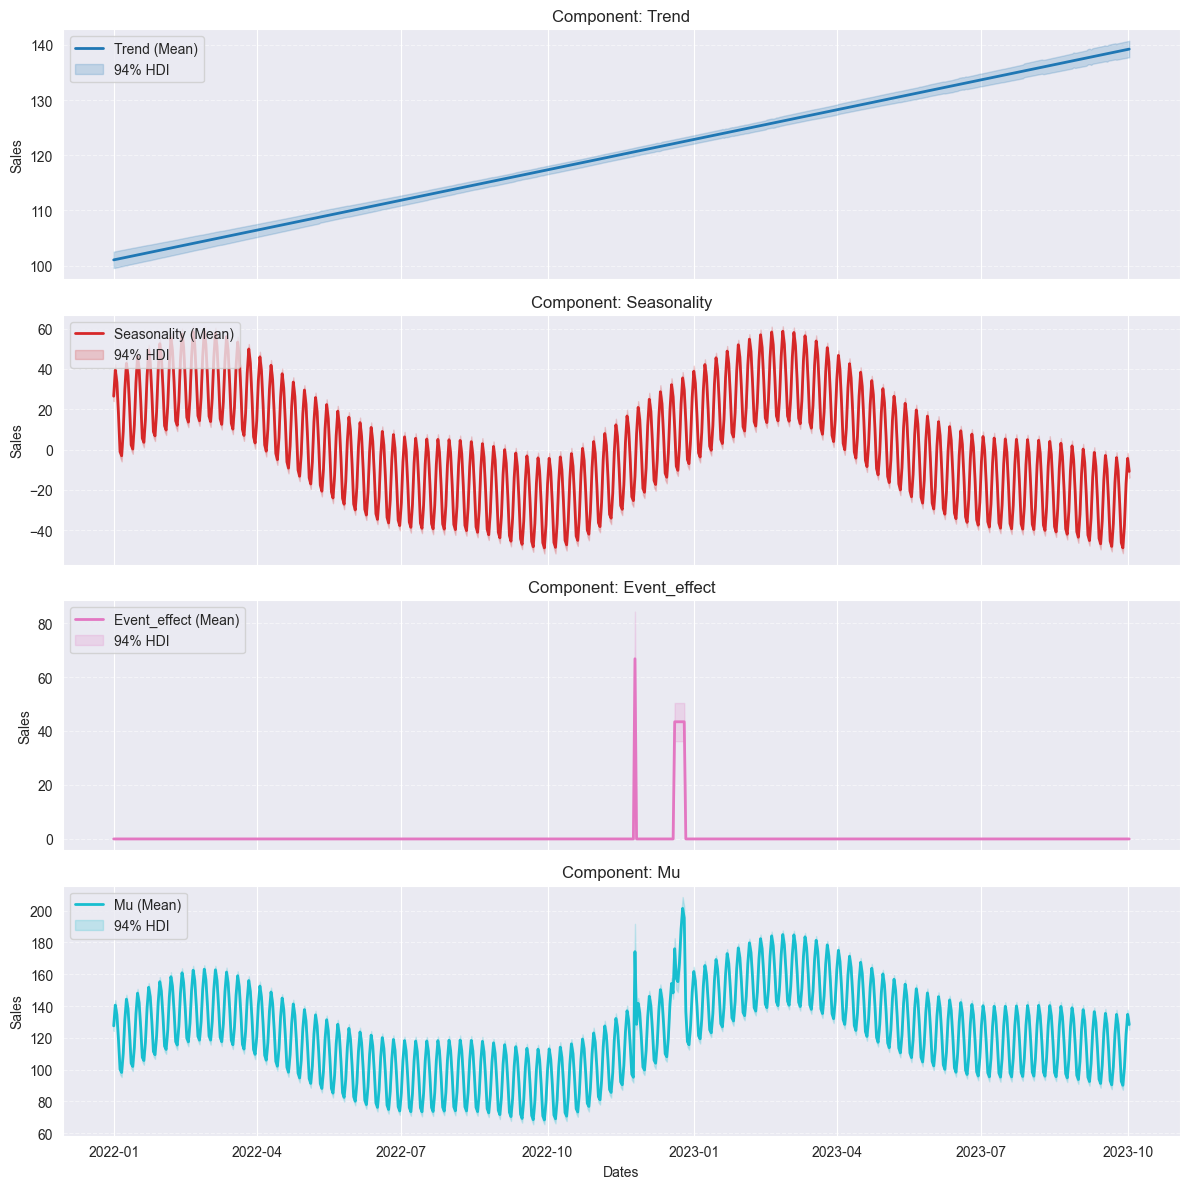

In [5]:
fig, axes = bayes_model.plot_components()

### Forecast

We ask the model to predict the 90 held-out days. The key API change from older versions: use `forecast(scenario={"df_future": ..., "date_col": ...})` instead of `predict()`.

The forecast generates posterior predictive samples for each future date, inheriting full parameter uncertainty from the posterior. The 94% HDI will be wider in periods the model is less certain about (e.g., around the Christmas event, where the prior is uncertain about the event magnitude).

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sampling: [y]


Output()

BayesTimeSeries SMAPE: 7.20%


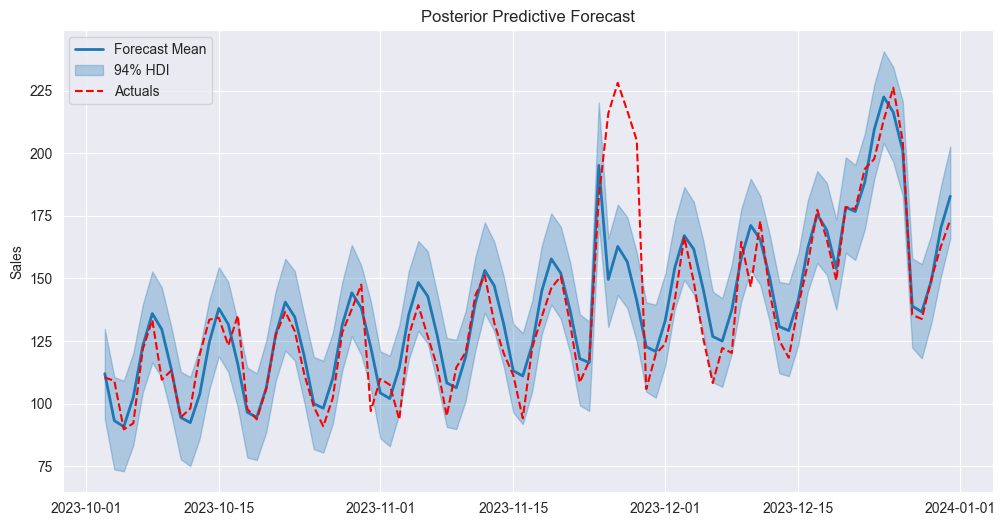

In [6]:
from optistock.forecasting.base import ErrorEstimations

df_future_b = pd.DataFrame({
    "date": pd.date_range(pd.to_datetime(df_test_b["date"].iloc[0]), periods=90)
})

# forecast() replaces the old predict() — future data is passed via a scenario dict
idata_forecast_b = bayes_model.forecast(scenario={"df_future": df_future_b, "date_col": "date"})

# plot_forecast() now returns values in the original (unscaled) sales units
fig, ax = bayes_model.plot_forecast()
ax.plot(
    pd.to_datetime(df_test_b["date"]),
    df_test_b["sales"],   # already in original scale — no division needed
    "r--", lw=1.5, label="Actuals",
)
ax.legend()

# SMAPE — both arrays in original scale
actual_orig     = df_test_b["sales"].values
forecast_mean_b = (
    idata_forecast_b.predictions["y"]
    .mean(dim=("chain", "draw"))
    .values
    * bayes_model.max_scaler
)
smape = ErrorEstimations.calculate_smape
print(f"BayesTimeSeries SMAPE: {smape(actual_orig, forecast_mean_b):.2f}%")

### Demand distribution for inventory planning

`get_demand_distribution(start, end)` sums the posterior predictive over a planning window, producing a distribution of *total* demand — exactly what `ForecastSolver` needs to optimise stock levels.

The red line shows the true total demand over the period. A well-calibrated model will have that line well inside the distribution.

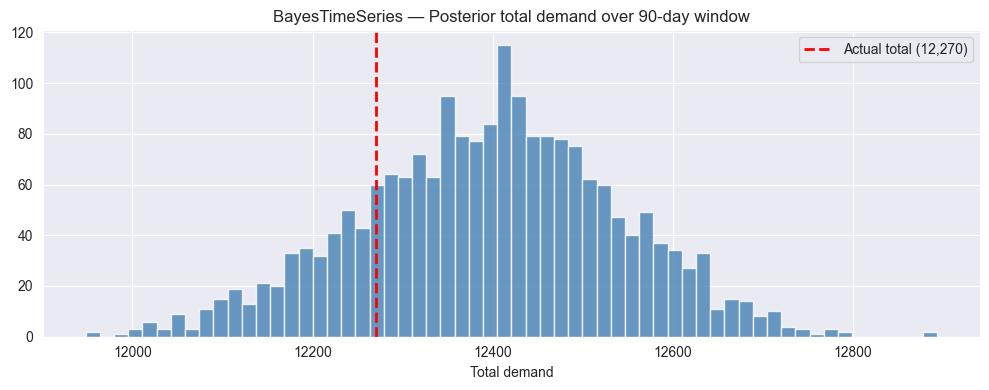

In [7]:
fc_start_b = df_test_b["date"].iloc[0]
fc_end_b   = df_test_b["date"].iloc[-1]

dist_b = bayes_model.get_demand_distribution(start_date=fc_start_b, end_date=fc_end_b)
total_demand_b = dist_b.demand.values.flatten()
actual_total_b = df_test_b["sales"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(total_demand_b, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(actual_total_b, color="red", linestyle="--", lw=2, label=f"Actual total ({actual_total_b:,.0f})")
ax.set_title("BayesTimeSeries — Posterior total demand over 90-day window")
ax.set_xlabel("Total demand")
ax.legend()
plt.tight_layout()

---
## Model 2: Marketing Mix Model (MMM)

**When to use:** sales vary primarily because of *marketing spend*, not calendar time. You need to attribute revenue to channels and quantify ROI.

The MMM applies two transformations to each channel's spend before adding it to a baseline:

1. **Adstock (carry-over):** `GeometricAdstock(l_max=8)` — this week's TV impression lingers for up to 8 weeks. The decay rate `alpha` controls how fast the effect fades. A high-alpha TV campaign creates a visible "tail" in the sales data after the campaign ends.

2. **Saturation (diminishing returns):** `LogisticSaturation()` — doubling spend does not double sales. The S-curve flattens as spend increases, capturing the diminishing-returns behaviour observed in real campaigns.

$$\text{sales}(t) = \text{baseline} + \sum_k \underbrace{\sigma\!\left(\text{adstock}(\text{spend}_k, \alpha_k)\right)}_{\text{channel }k} + \varepsilon$$

**Advantage over BayesTimeSeries:** explicitly separates baseline from channel contribution — you can answer "how much did the November TV campaign generate?"  
**Advantage over SSM:** designed for causal marketing questions; spend scenarios for budget planning.  
**Weakness:** requires historical spend data for every channel; won't learn seasonality without yearly_seasonality parameter.

In [8]:
from optistock.forecasting.mix_media_models import MediaMixModel

# Withhold last 20 weeks for validation
df_train_m = df_mmm.iloc[:-20].copy()
df_test_m  = df_mmm.iloc[-20:].copy()

mmm_model = MediaMixModel(
    data=df_train_m,
    target_col="sales",
    date_col="date",
    channel_columns=["tv_spend", "digital_spend"],
    yearly_seasonality=None,   # variation is spend-driven, not calendar-driven
    time_varying_intercept=True
)

idata_m = mmm_model.fit(draws=500, chains=2, nuts_sampler="nutpie")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.09,127
,1500,0,0.19,31


Output()

### Channel contribution

`plot_components()` shows the time-series contribution of each marketing channel. In dataset 2 the TV contribution should mirror the burst campaigns (with a visible adstock tail after each campaign ends), while digital should be a smoother, lower baseline contribution — reflecting the saturation effect at always-on spend levels.

This is the primary output that marketing teams use to justify budget reallocation.

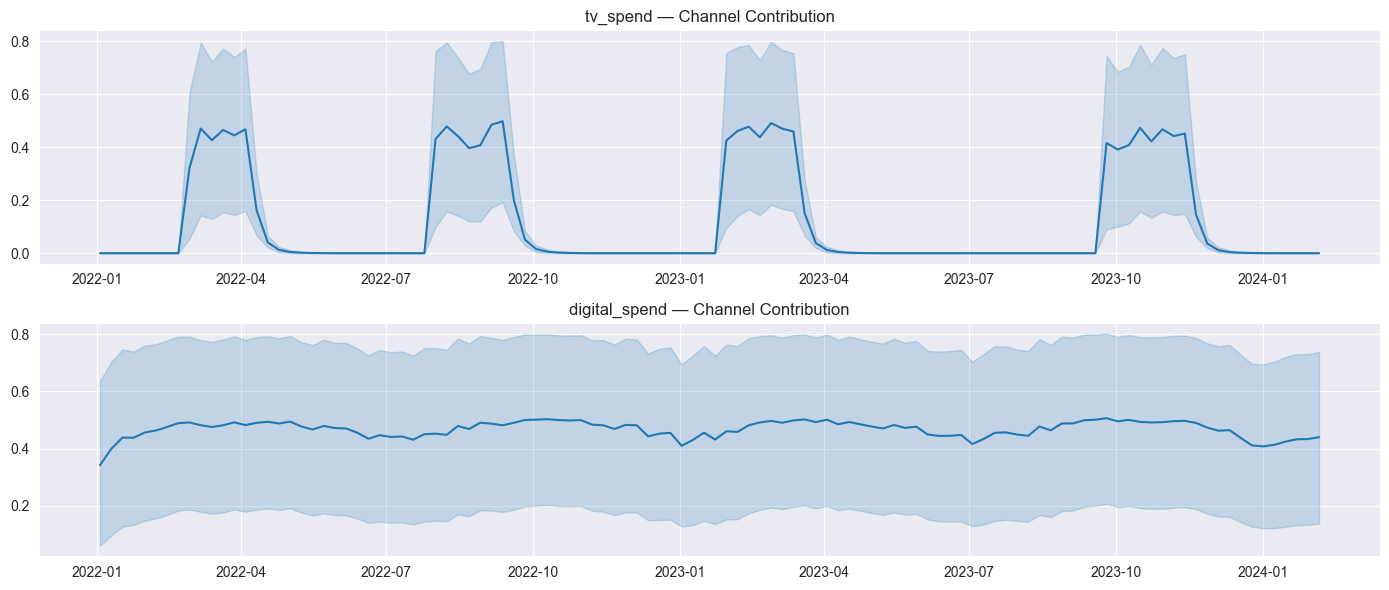

In [9]:
fig, axes = mmm_model.plot_components()

### Spend scenario forecast

`forecast(df_future)` takes a dataframe with the planned spend for each future week. This lets you run **what-if scenarios** before committing budget: "what is the demand distribution if we run a TV campaign in week 5 of the planning window?"

The held-out test weeks use the same spend that was generated synthetically, so the model should track the actual sales well.

Sampling: [y]


Output()

MediaMixModel SMAPE: 14.40%


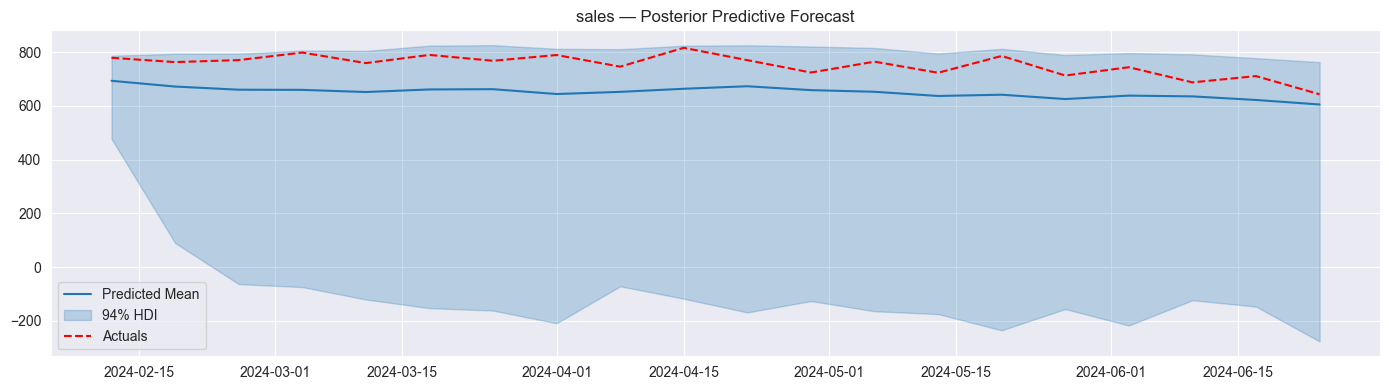

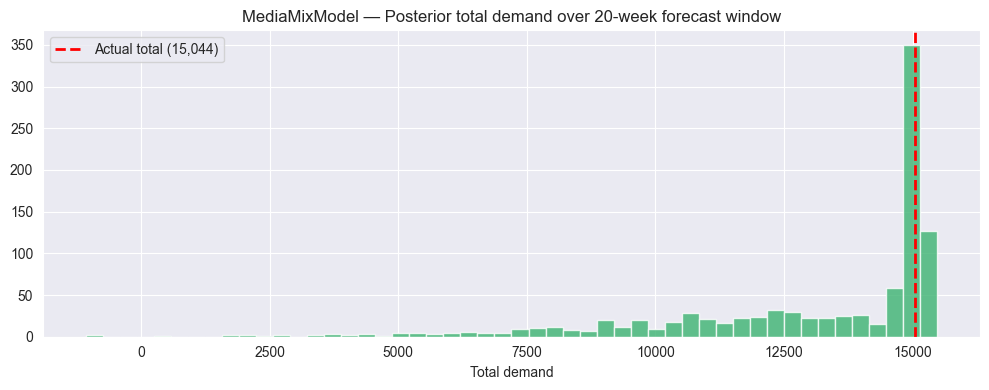

In [15]:
from optistock.forecasting.base import ErrorEstimations

df_future_m = df_test_m[["date", "tv_spend", "digital_spend"]].copy()
predictions_m = mmm_model.forecast(df_future=df_future_m)

fig, ax = mmm_model.plot_forecast()
ax.plot(df_test_m["date"], df_test_m["sales"], "r--", lw=1.5, label="Actuals")
ax.legend()

# SMAPE
smape = ErrorEstimations.calculate_smape
forecast_mean_m = predictions_m.mean(dim="sample").values
smape_m = smape(df_test_m["sales"].values, forecast_mean_m)
print(f"MediaMixModel SMAPE: {smape_m:.2f}%")

# Demand distribution
fc_start_m = str(df_test_m["date"].iloc[0].date())
fc_end_m   = str(df_test_m["date"].iloc[-1].date())
dist_m = mmm_model.get_demand_distribution(start_date=fc_start_m, end_date=fc_end_m)

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.hist(dist_m.demand, bins=50, color="mediumseagreen", edgecolor="white", alpha=0.8)
ax2.axvline(df_test_m["sales"].sum(), color="red", linestyle="--", lw=2,
            label=f"Actual total ({df_test_m['sales'].sum():,.0f})")
ax2.set_title("MediaMixModel — Posterior total demand over 20-week forecast window")
ax2.set_xlabel("Total demand")
ax2.legend()
plt.tight_layout()

---
## Model 3: Univariate State Space Model (SSM)

**When to use:** the underlying data-generating process *changes over time* — the trend reverses, the seasonal amplitude grows, or there is a structural break you don't want to hard-code as a dummy variable.

The SSM frames the time series as a **latent state process** observed with noise. The key components:

- **LevelTrend (order=2):** a local level ($\mu_t$) plus a local slope ($\nu_t$), both allowed to drift at every step:

$$\mu_t = \mu_{t-1} + \nu_{t-1} + \eta_{\mu}, \quad \nu_t = \nu_{t-1} + \eta_{\nu}$$

  When the slope innovations $\eta_\nu$ are non-zero, the model can smoothly reverse direction without any explicit break-point.

- **FrequencySeasonality with innovations:** the seasonal amplitudes themselves can drift, so the model follows the dataset 3 feature where the seasonal swing doubles over time.

Inference uses a **Kalman filter** (likelihood evaluation) and **Kalman smoother** (posterior decomposition), both with PyMC/JAX for GPU acceleration.

**Advantage over BayesTimeSeries:** handles structural breaks and time-varying seasonal amplitude with no manual specification.  
**Advantage over MMM:** pure time-series model — no exogenous variables required.  
**Weakness:** slower to fit; requires `smooth_and_filter()` before component inspection.

In [11]:
from optistock.forecasting.state_space import UnivariateSSM

# Withhold last 6 months for validation
df_train_s = df_ssm.iloc[:-6]
df_test_s  = df_ssm.iloc[-6:]

ssm_model = UnivariateSSM(data=df_train_s, target_col="sales")

# trend_innovations_order=[0, 1]: the slope can drift each step, the level
# is deterministic given the slope — gives a smooth but flexible trend.
# seasonal_innovations=True: seasonal amplitudes can evolve over time.
ssm_model.build_model(
    trend_order=2,
    trend_innovations_order=[0, 1],
    seasonal_period=12,
    seasonal_harmonics=2,
    seasonal_innovations=True,
)

ssm_model.fit(
    sampler="nutpie",
    draws=500,
    tune=500,
    chains=2,
    target_accept=0.90,
)

                                Model Requirements                                
                                                                                  
  Variable              Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                              ('state_level_trend',)  
  sigma_level_trend     (1,)     Positive                 ('shock_level_trend',)  
  params_seasonal       (4,)                                 ('state_seasonal',)  
  sigma_seasonal        ()       Positive                                   None  
  sigma_obs             ()       Positive                                   None  
  P0                    (6, 6)   Positive semi-definite   ('state', 'state_aux')  
                                                                                  
   These parameters should be assigned priors inside a PyMC model block before    
                    calling the build_statespace_graph method.                    

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pymc_extras\statespace\utils\data_tools.py:92: UserWarning: No frequency was specific on the data's DateTimeIndex.
  warnings.warn(NO_FREQ_INFO_WARNING)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,1,0.52,7
,1000,0,0.46,7


### In-sample fit and component decomposition

`smooth_and_filter()` runs the Kalman smoother, which gives the posterior over each latent state at every observed time step. Unlike the Fourier model, the SSM states (level, slope, seasonal amplitudes) are not fixed functions of time — they are random variables whose posterior is informed by the data on both sides of each point.

`plot_fit()` overlays the smoothed posterior on the training data — the 50% and 95% HDIs should tightly track the data through the trend reversal.  
`plot_components()` shows the individual latent states. Look for the slope state to change sign around month 20, and for the seasonal amplitude to gradually increase.

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x2D89A96D380>), RNG(<Generator(PCG64) at 0x2D89A96FD80>), RNG(<Generator(PCG64) at 0x2D89DD44740>), RNG(<Generator(PCG64) at 0x2D89DD45380>), RNG(<Generator(PCG64) at 0x2D89DD44900>), RNG(<Generator(PCG64) at 0x2D89DD449E0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Variables filtered_posterior_observed, predicted_posterior_observed, smoothed_posterior_observed do not contain all hidden states (their last dimension is not 6). They will not be present in the modified idata.


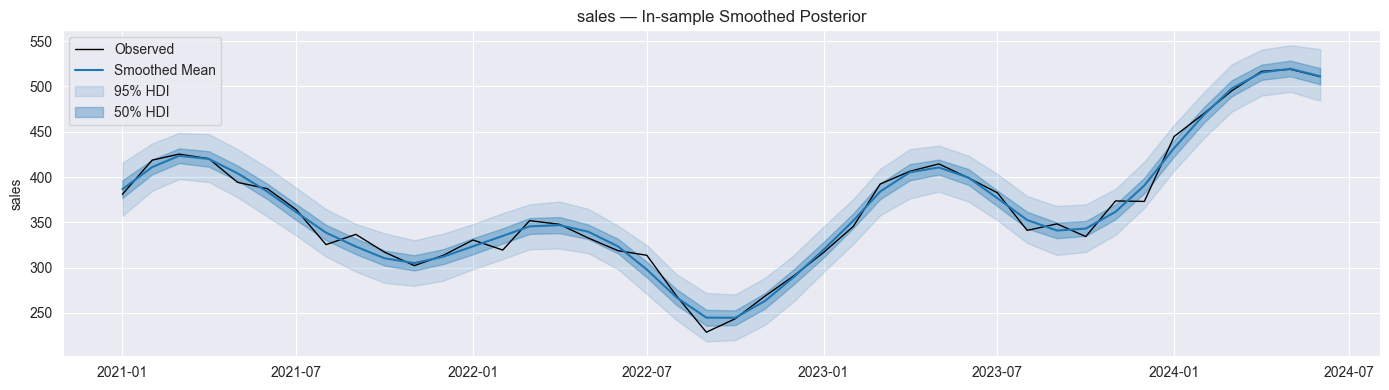

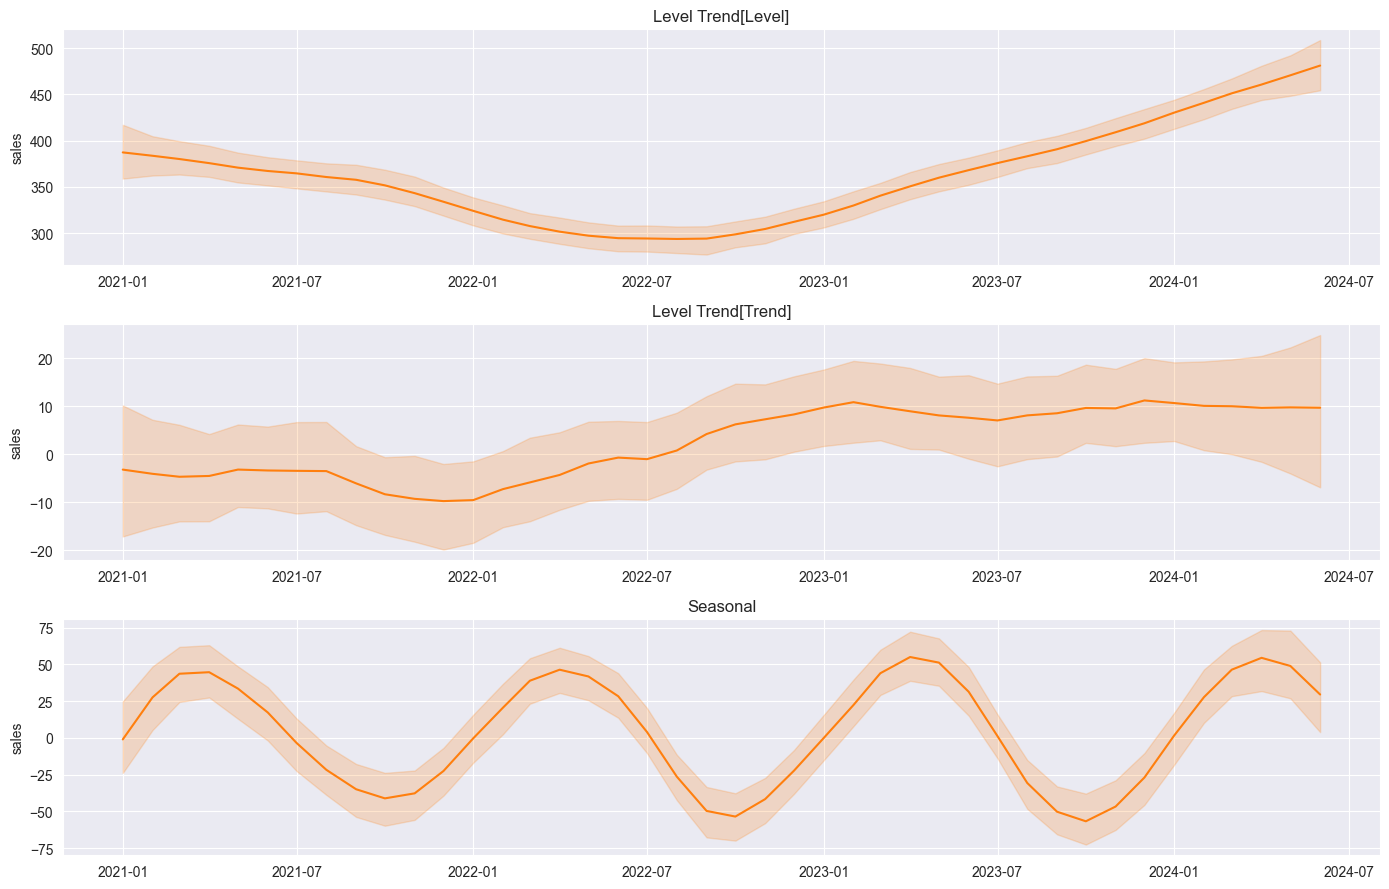

In [12]:
ssm_model.smooth_and_filter()

fig_fit, ax_fit   = ssm_model.plot_fit()
fig_comp, ax_comp = ssm_model.plot_components()

### Out-of-sample forecast

`forecast(periods=n)` extends the Kalman smoother forward using the posterior parameter distribution. A key property of the SSM forecast is **naturally growing uncertainty**: because both the trend slope and seasonal amplitudes are allowed to drift, the HDI fans out over the horizon — unlike the Fourier model, which projects the same fixed pattern with the same fixed uncertainty indefinitely.

c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\jax\linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x2D9575C6C00>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
Sampling: [forecast_combined]


Output()

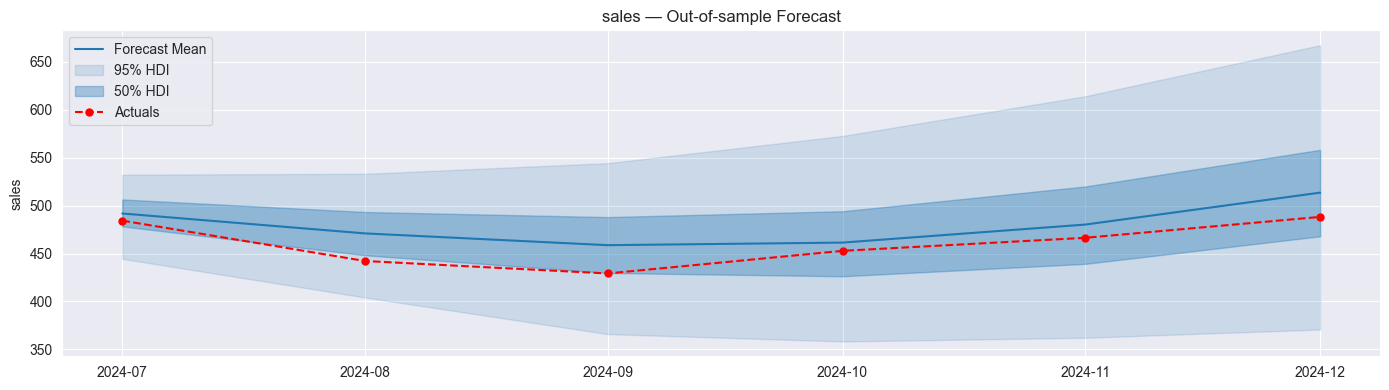

In [13]:
idata_forecast_s = ssm_model.forecast(periods=6)

fig_fc, ax_fc = ssm_model.plot_forecast()
ax_fc.plot(df_test_s.index, df_test_s["sales"], "ro--", ms=5, lw=1.5, label="Actuals")
ax_fc.legend()

### Demand distribution

`get_demand_distribution()` sums the forecast posterior across the planning window, accounting for both process noise (drifting states) and measurement noise. This gives a wider distribution than the Fourier model for the same horizon length — appropriate for a situation where the trend direction itself is uncertain.

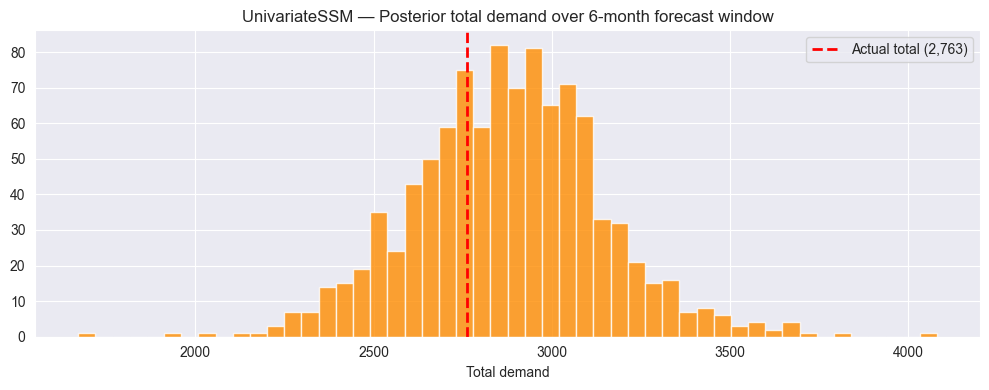

In [14]:
fc_start_s = str(df_test_s.index[0].date())
fc_end_s   = str(df_test_s.index[-1].date())

dist_s = ssm_model.get_demand_distribution(start_date=fc_start_s, end_date=fc_end_s)
total_demand_s = dist_s["demand"].values.flatten()
actual_total_s = df_test_s["sales"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(total_demand_s, bins=50, color="darkorange", edgecolor="white", alpha=0.8)
ax.axvline(actual_total_s, color="red", linestyle="--", lw=2,
           label=f"Actual total ({actual_total_s:,.0f})")
ax.set_title("UnivariateSSM — Posterior total demand over 6-month forecast window")
ax.set_xlabel("Total demand")
ax.legend()
plt.tight_layout()

---
## Model Selection Guide

| | BayesTimeSeries | MediaMixModel | UnivariateSSM |
|---|---|---|---|
| **Data frequency** | Daily / Weekly | Weekly / monthly | Weekly / Monthly |
| **Key driver** | Calendar time | Marketing spend | Latent state dynamics |
| **Stable seasonality** | ✓ Best fit | ◑ Needs `yearly_seasonality` | ✓ Handles it |
| **Structural breaks** | ✗ Struggles | ✗ Struggles | ✓ Core strength |
| **Channel attribution** | ✗ Not designed for | ✓ Core feature | ✗ Can, but not for budgeting |
| **Event effects** | ✓ `create_events()` | ◑ Via `control_columns` | ◑ Via `exog` |
| **Exogenous data needed** | Optional (events) | Required (spend) | Optional |
| **Fitting speed** | Fast | Moderate | Slow (Kalman + MCMC) |

### Connecting to ForecastSolver

All three models share the same downstream interface:

```python
from optistock.solvers import ForecastSolver
from optistock.items import Item

item  = Item("product", cost_price=10, selling_price=25, salvage_value=3)

# fitted_model is any of: bayes_model, mmm_model, ssm_model
solver = ForecastSolver([(item, fitted_model)])
allocation = solver.solve(start_date="2024-01-01", end_date="2024-03-31")
```

`ForecastSolver` calls `fitted_model.get_demand_distribution(start, end)` internally, so switching models requires no changes to the solver code.

### Accessing the demand distribution

All three models return a `xr.Dataset` with a `"demand"` key from `get_demand_distribution()`, consistent with what `ForecastSolver._pull_demand` expects:

```python
dist = fitted_model.get_demand_distribution(start_date, end_date)
total_demand = dist["demand"].values.flatten()   # works for all three models
```